# Coffee Sales Analysis
Comprehensive business analysis of coffee sales transactions using reusable functions from the src package.

Last updated: 2026-03-27

## Environment and Imports
Set up paths and import only reusable project modules for ingestion, validation, cleaning, feature engineering, analysis, and plotting.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(project_root / "src") not in sys.path:
    sys.path.append(str(project_root / "src"))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from analysis.product_analysis import (
    best_product_per_time_of_day,
    top_products_by_revenue,
    top_products_by_volume,
)
from analysis.sales_analysis import sales_overview
from analysis.time_analysis import hourly_sales, peak_weekday_hour, revenue_by_month, revenue_by_weekday
from cleaning.clean_data import clean_sales_data
from config import settings
from features.time_features import derive_time_features
from ingestion.load_data import load_raw_sales_data
from validation.schema import assert_valid_dataset
from visualization.plots import (
    plot_hour_product_heatmap,
    plot_hourly_revenue,
    plot_monthly_revenue,
    plot_time_product_heatmap,
    plot_top_products,
    plot_weekday_revenue,
)

## Data Preparation
Load raw data, validate schema constraints, clean records, and derive additional time features before analysis.

In [3]:
raw_df = load_raw_sales_data(settings.raw_data_path)
assert_valid_dataset(raw_df)

clean_df = clean_sales_data(raw_df)
analysis_df = derive_time_features(clean_df)

print(f"Raw rows: {raw_df.shape[0]}")
print(f"Rows after cleaning: {clean_df.shape[0]}")
print(f"Rows used for analysis: {analysis_df.shape[0]}")

Raw rows: 3547
Rows after cleaning: 3547
Rows used for analysis: 3547


In [ ]:
display(analysis_df.head())

## Sales Overview
Answer baseline business questions: total transactions, total revenue, average ticket size, and product diversity.

In [4]:
overview = sales_overview(analysis_df)
overview_df = pd.DataFrame([overview])
display(overview_df)

,transactions,total_revenue,average_transaction_value,unique_products
0,3547,112245.58,31.645216,8


## Time-Based Analysis
Evaluate revenue and transaction behavior by hour, weekday, and month to identify operational peaks and trend structure.

In [5]:
hourly_df = hourly_sales(analysis_df)
weekday_df = revenue_by_weekday(analysis_df)
monthly_df = revenue_by_month(analysis_df)

display(hourly_df.head())
display(weekday_df)
display(monthly_df)

,hour_of_day,transactions,revenue
0,6,5,149.40
1,7,88,2846.02
2,8,235,7017.88
3,9,242,7264.28
4,10,328,10198.52


,Weekdaysort,Weekday,revenue
0,1,Mon,17363.10
1,2,Tue,18168.38
2,3,Wed,15750.46
3,4,Thu,16091.40
4,5,Fri,16802.66
5,6,Sat,14733.52
6,7,Sun,13336.06


,Monthsort,Month_name,revenue
0,1,Jan,6398.86
1,2,Feb,13215.48
2,3,Mar,15891.64
3,4,Apr,5719.56
4,5,May,8164.42
5,6,Jun,7617.76
6,7,Jul,6915.94
7,8,Aug,7613.84
8,9,Sep,9988.64
9,10,Oct,13891.16


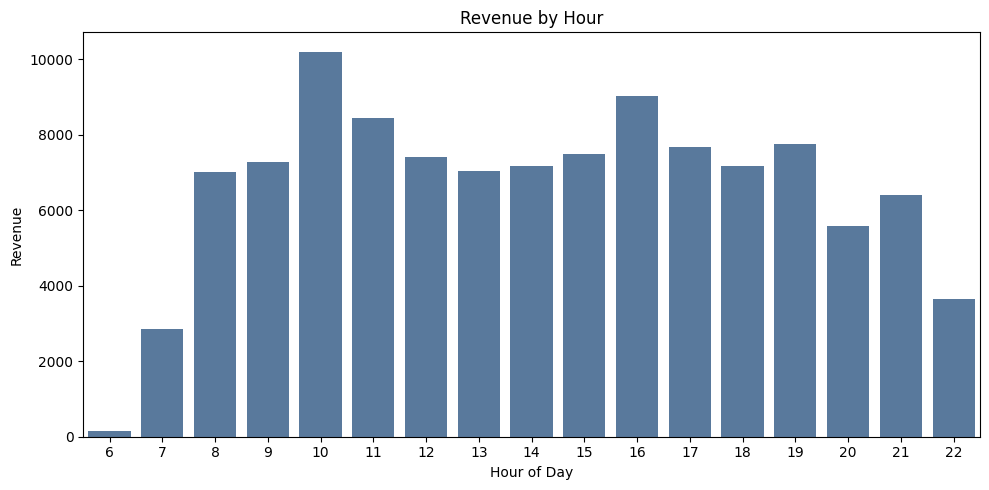

In [6]:
fig = plot_hourly_revenue(hourly_df)
plt.tight_layout()
plt.show()

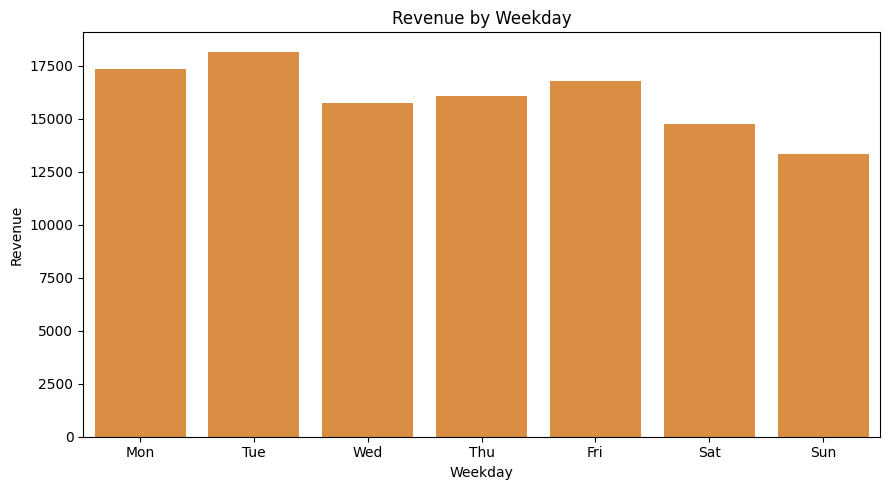

In [7]:
fig = plot_weekday_revenue(weekday_df)
plt.tight_layout()
plt.show()

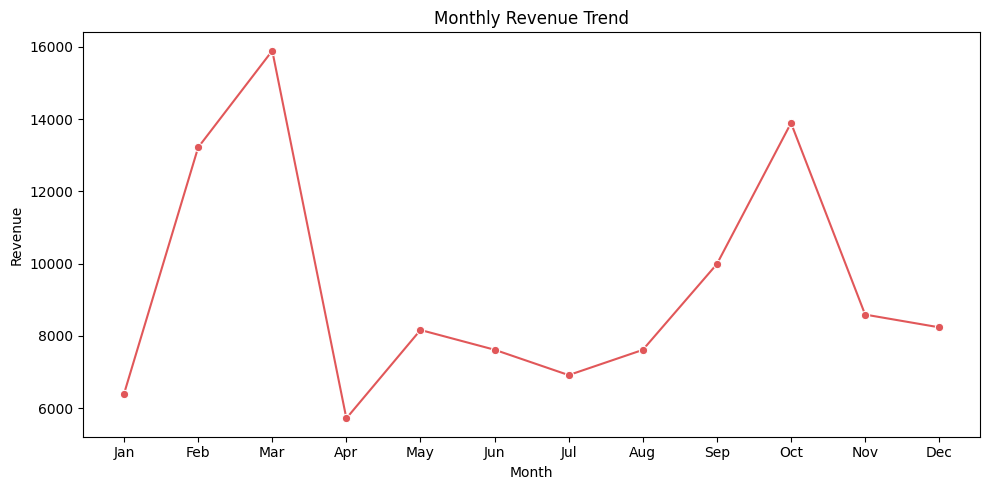

In [8]:
fig = plot_monthly_revenue(monthly_df)
plt.tight_layout()
plt.show()

In [9]:
peak_hour = hourly_df.sort_values(["transactions", "revenue"], ascending=False).head(1)
peak_weekday = weekday_df.sort_values("revenue", ascending=False).head(1)

display(peak_hour)
display(peak_weekday)

,hour_of_day,transactions,revenue
4,10,328,10198.52


,Weekdaysort,Weekday,revenue
1,2,Tue,18168.38


## Product Performance Analysis
Assess product winners by volume and revenue, then compare behavior by time-of-day segments.

In [10]:
top_volume_df = top_products_by_volume(analysis_df, n=8)
top_revenue_df = top_products_by_revenue(analysis_df, n=8)
best_tod_df = best_product_per_time_of_day(analysis_df)

display(top_volume_df)
display(top_revenue_df)
display(best_tod_df)

,coffee_name,quantity
0,Americano with Milk,809
1,Latte,757
2,Americano,564
3,Cappuccino,486
4,Cortado,287
5,Hot Chocolate,276
6,Cocoa,239
7,Espresso,129


,coffee_name,revenue
0,Latte,26875.30
1,Americano with Milk,24751.12
2,Cappuccino,17439.14
3,Americano,14650.26
4,Hot Chocolate,9933.46
5,Cocoa,8521.16
6,Cortado,7384.86
7,Espresso,2690.28


,Time_of_Day,coffee_name,quantity,revenue
0,Afternoon,Latte,270,9611.10
1,Morning,Americano with Milk,331,10025.52
2,Night,Latte,272,9614.02


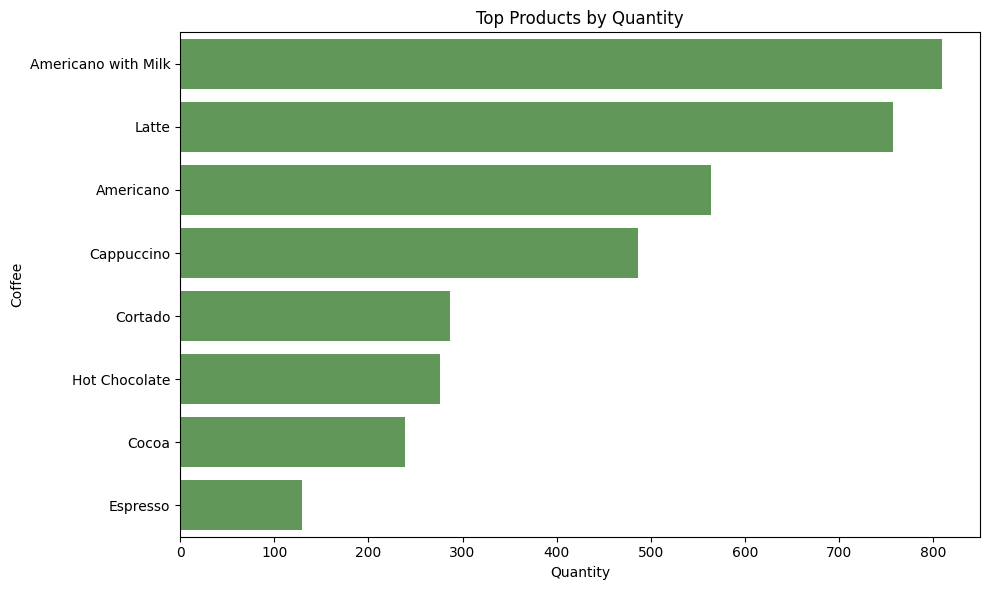

In [11]:
fig = plot_top_products(top_volume_df, value_column="quantity")
plt.tight_layout()
plt.show()

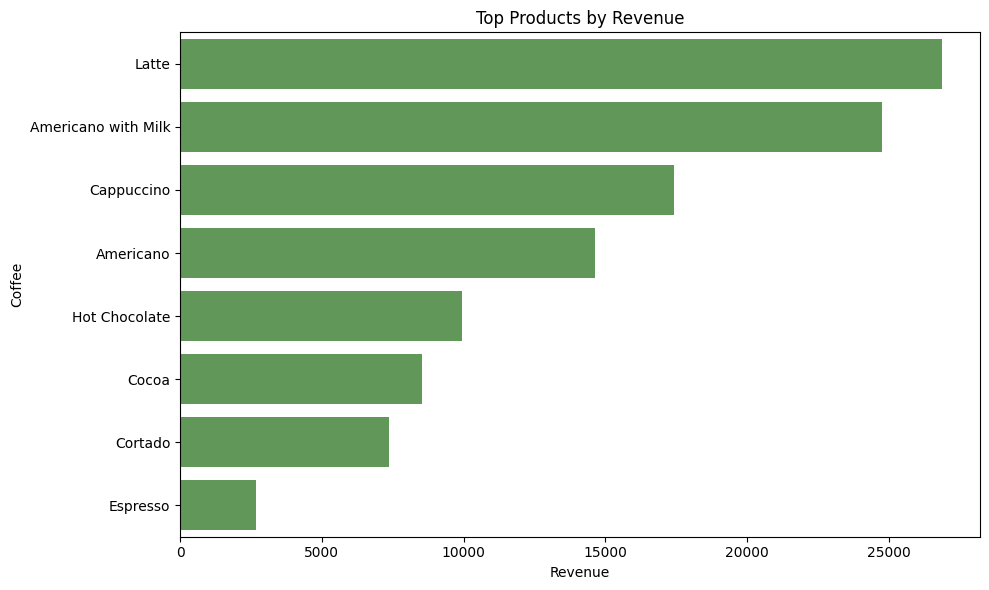

In [12]:
fig = plot_top_products(top_revenue_df, value_column="revenue")
plt.tight_layout()
plt.show()

In [13]:
avg_ticket_product = (
    analysis_df.groupby("coffee_name", as_index=False)["money"]
    .mean()
    .rename(columns={"money": "avg_ticket"})
    .sort_values("avg_ticket", ascending=False)
)
display(avg_ticket_product)

,coffee_name,avg_ticket
6,Hot Chocolate,35.990797
2,Cappuccino,35.883004
3,Cocoa,35.653389
7,Latte,35.502378
1,Americano with Milk,30.594710
0,Americano,25.975638
4,Cortado,25.731220
5,Espresso,20.854884


## Behavioral Pattern Analysis
Use heatmaps and peak combination analysis to uncover hour-product and time-product concentration patterns.

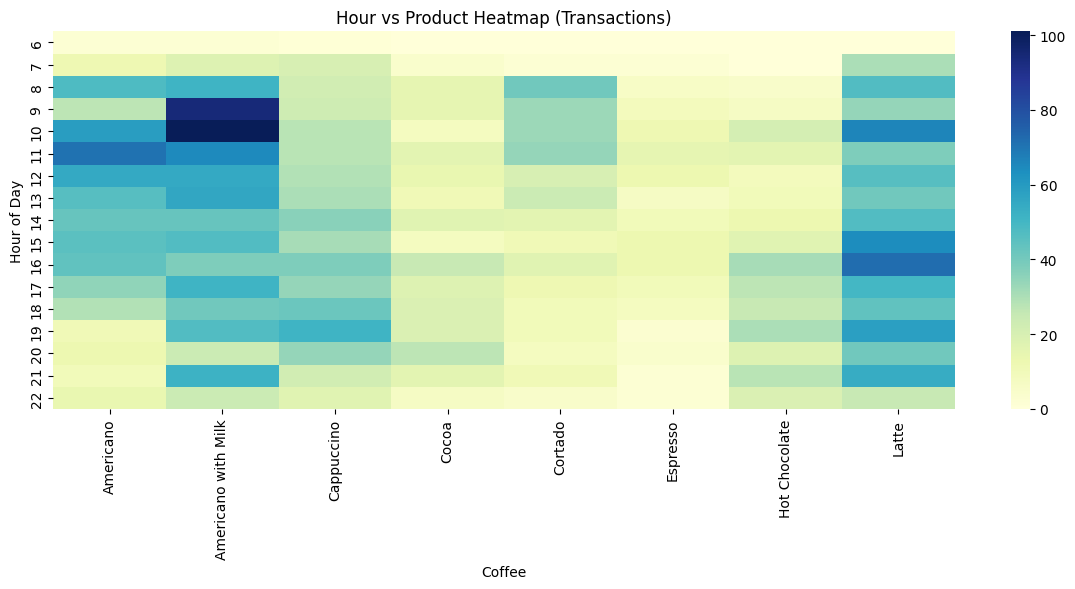

In [14]:
fig = plot_hour_product_heatmap(analysis_df)
plt.tight_layout()
plt.show()

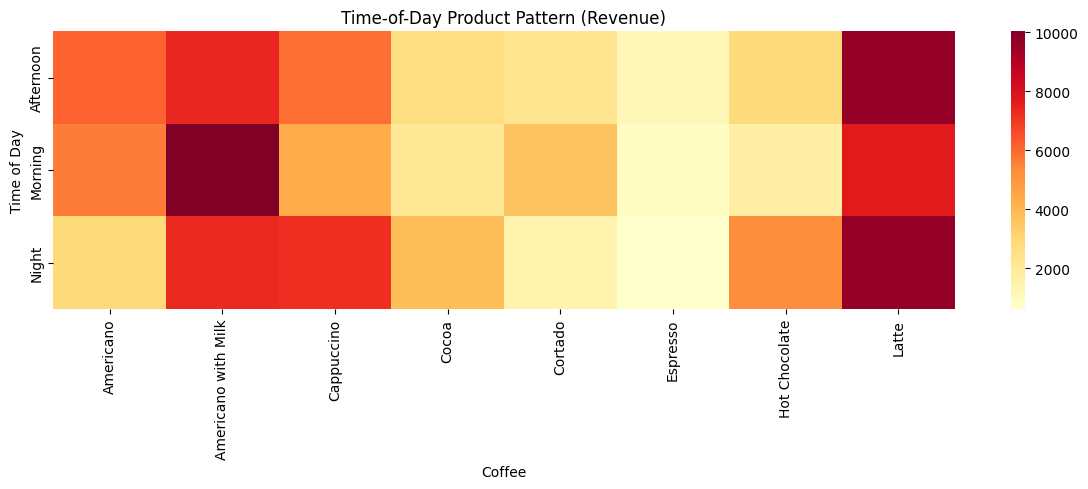

In [15]:
fig = plot_time_product_heatmap(analysis_df)
plt.tight_layout()
plt.show()

In [16]:
weekday_hour_df = peak_weekday_hour(analysis_df)
display(weekday_hour_df.head(15))

,Weekday,hour_of_day,transactions,revenue
0,Tue,19,52,1737.02
1,Tue,11,56,1728.16
2,Mon,10,52,1650.78
3,Sat,11,55,1602.24
4,Tue,16,50,1599.84
5,Sun,10,47,1543.52
6,Mon,16,46,1540.10
7,Fri,9,51,1493.50
8,Thu,19,43,1486.72
9,Thu,10,49,1486.66


## Key Business Answers
This section summarizes direct answers to the core and supporting analytical questions.

In [17]:
overall_avg_ticket = analysis_df["money"].mean()
lowest_tx_weekday = (
    analysis_df.groupby(["Weekdaysort", "Weekday"], as_index=False)
    .agg(transactions=("money", "size"))
    .sort_values(["transactions", "Weekdaysort"])
    .head(1)
)

print(f"Average transaction value overall: {overall_avg_ticket:.2f}")
display(lowest_tx_weekday)
display(best_tod_df)

Average transaction value overall: 31.65


,Weekdaysort,Weekday,transactions
6,7,Sun,419


,Time_of_Day,coffee_name,quantity,revenue
0,Afternoon,Latte,270,9611.10
1,Morning,Americano with Milk,331,10025.52
2,Night,Latte,272,9614.02


## Summary
- The notebook uses only reusable functions from src for ingestion, validation, cleaning, feature derivation, analysis, and visualization.
- Peak periods are identified with hourly, weekday, and month-level revenue views.
- Product strategy is supported through ranking by both transaction volume and total revenue.
- Time-of-day preference patterns are shown using best-product tables and transaction/revenue heatmaps.
- Cash method comparison is intentionally limited because the current dataset contains card transactions only.